---
numbering: false
---

# LW1: Least-Squares Problems

{button}`Launch in Colab <https://githubtocolab.com/jflamant/mines-nancy-optimization/blob/main/labs/LW1.ipynb>`
{button}`Download .ipynb file <https://github.com/jflamant/mines-nancy-optimization/blob/main/labs/LW1.ipynb>`

In this notebook, we will explore some **least-squares problems**, one of the first fundamental optimization problems encountered in this course. We'll focus on two classical problems:
- Polynomial regression
- Denoising a signal using least-squares and *regularizers* or *penalization* methods.

This first TP involves the practical implementation of least-squares problems using two classical Python libraries:
1. **NumPy**: For efficient numerical computations, matrix operations, and solving least-squares problems using built-in linear algebra functions.
2. **Matplotlib**: For visualizing the data and displaying / interpreting results.

### Running the Notebook
This notebook can be executed in the following environments:
- **Google Colab**: A convenient, cloud-based option that requires no setup. Simply open the notebook in Colab, and you're ready to run the code.
- **Locally**: You can run the notebook on your local machine using environments like **JupyterLab** or **Jupyter Notebook**. You can also run it directly in **Visual Studio Code** if you have the Jupyter extension. In all cases, ensure you have Python installed along with the required libraries, `NumPy` and `Matplotlib`.

In [1]:
# load necessary dependencies
import numpy as np
import matplotlib.pyplot as plt

###  1. Polynomial regression

This first exercise will permit to review basic instructions in Python as well as standard functions from NumPy and Matplotlib. The goal is to estimate the parameters of a polynomial model given experimental (i.e. noisy) data using the least-squares method.
We'll first define the *true* model, generate some noisy synthetic data, and then estimate the model parameters.

Consider the *ground truth* polynomial model $y_{\text{true}}(t) = 10t^3 + 3t^2 + 2t + 1$ for $t\in \mathbb{R}$.

**Questions**

1. Represent the function $y_{\text{true}}(t)$ on $[-1, 1]$.
2. Given $N =10$ equispaced time instants $t_1, \ldots, t_N$ over $[-1, 1]$, generate a noisy vector of measurements $\mathbf{y} \in \mathbb{R}^N$ with entries $y_n = y(t_n) = y_{\text{true}}(t) + \epsilon$, where $\epsilon \sim \mathcal{N}(0, 1)$ is Gaussian. Represent noisy measurements and the ground truth model on the same graph.
3. From the data $\mathbf{y}$, we wish to fit a polynomial model of order $d < 10$ of the form
$$y_{\text{model}}(t) = x_0 + x_1 t + x_2 t^2 + \ldots + x_{d+1}t^d$$
Write the linear model matrix $\mathbf{A}$ for an arbitrary order $d$. Construct this matrix numerically, given $d$ and the vector of time instants $\mathbf{t} = [t_1, t_2, \ldots, t_N]$. (Hint: check the ``np.vander`` function).

4. Given an integer $d <10$, write and solve the associated least squares problem. Display the estimated vector of coefficients. Compare the solution obtained by the explicit expression and that obtained with the ``np.linalg.pinv`` function.
5. Represent the estimated polynomial model for several values of $d$ (say $d=1, 3, 7$). Comment. What happens for $d=9$?
6. (Bonus) The choice of the degree of the polynomial can be evaluated using a standard criterion such as Akaike Information Criterion, defined as $\text{AIC} = 2p + 2\log r^2$, where $p$ is the number of parameters to be estimated and $r$ is the norm of the residual (in this context). Plot this criterion for the different choices of $d$. For each value of $d$ is the minimum attained?
7. (Bonus bis) Play around with differents values of $N$, true polynomial $y_{\text{true}}(t)$, or noise level $\sigma$!

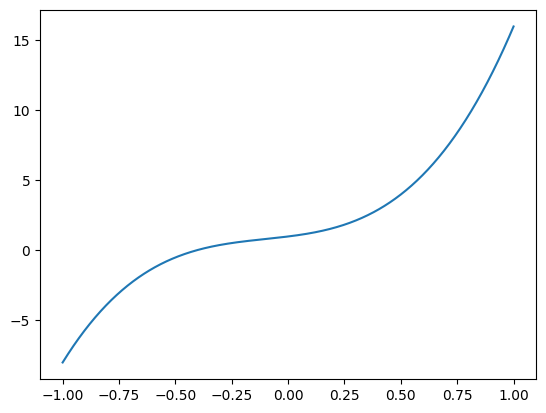

In [107]:
# question 1
def ytrue(t):
  return 10*t**3 + 3*t**2+2*t+1
x=np.linspace(-1,1,1000)
y=ytrue(x)
plt.plot(x,y)

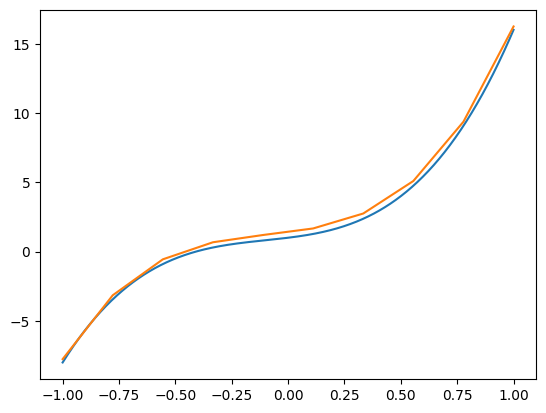

In [39]:
# question 2
import scipy.stats as stats
t = np.linspace(-1,1,10)
def bruit(t):
  return ytrue(t)+ stats.norm.pdf(t)
Y=bruit(t)
plt.plot(x,y)
plt.plot(t,Y)

In [49]:
# question 3

def matrice(t,d):
  A=np.vander(t,d+1, increasing=True)
  return A
matrice(t,3)

array([[ 1.        , -1.        ,  1.        , -1.        ],
       [ 1.        , -0.77777778,  0.60493827, -0.47050754],
       [ 1.        , -0.55555556,  0.30864198, -0.17146776],
       [ 1.        , -0.33333333,  0.11111111, -0.03703704],
       [ 1.        , -0.11111111,  0.01234568, -0.00137174],
       [ 1.        ,  0.11111111,  0.01234568,  0.00137174],
       [ 1.        ,  0.33333333,  0.11111111,  0.03703704],
       [ 1.        ,  0.55555556,  0.30864198,  0.17146776],
       [ 1.        ,  0.77777778,  0.60493827,  0.47050754],
       [ 1.        ,  1.        ,  1.        ,  1.        ]])

In [62]:
# question 4

def res_least_square(t,d):
  A=matrice(t,d)
  res=np.linalg.solve(A.T@A, A.T@Y)
  res2=np.linalg.pinv(A.T@A)@A.T@Y
  return res, res2


# On affiche les valeurs des coefficiants pour tous les degres. On conclut sur le degré 3
for i in range (10):
  print(res_least_square(t,i)[0])

[2.5527319]
[2.5527319 9.2345679]
[1.39416823 9.2345679  2.84374718]
[ 1.39416823  2.          2.84374718 10.        ]
[ 1.39875679  2.          2.80427919 10.          0.03898667]
[1.39875679e+00 2.00000000e+00 2.80427919e+00 1.00000000e+01
 3.89866655e-02 1.73226987e-13]
[ 1.39893856e+00  2.00000000e+00  2.80067976e+00  1.00000000e+01
  4.89574385e-02  1.73111159e-13 -6.60517379e-03]
[ 1.39893856e+00  2.00000000e+00  2.80067976e+00  1.00000000e+01
  4.89574385e-02  2.00294853e-11 -6.60517379e-03 -1.16165519e-11]
[ 1.39894226e+00  2.00000000e+00  2.80053102e+00  1.00000000e+01
  4.98390268e-02  2.00284270e-11 -8.19127957e-03 -1.16159481e-11
  8.49699526e-04]
[ 1.39894226e+00  2.00000000e+00  2.80053102e+00  1.00000000e+01
  4.98390268e-02  2.67140001e-09 -8.19127957e-03 -4.28760068e-09
  8.49699525e-04  2.16301148e-09]


array([-7.75802928e+00, -7.70560101e+00, -7.65338870e+00, -7.60139186e+00,
       -7.54961001e+00, -7.49804269e+00, -7.44668940e+00, -7.39554968e+00,
       -7.34462305e+00, -7.29390903e+00, -7.24340714e+00, -7.19311690e+00,
       -7.14303784e+00, -7.09316948e+00, -7.04351135e+00, -6.99406295e+00,
       -6.94482383e+00, -6.89579350e+00, -6.84697148e+00, -6.79835729e+00,
       -6.74995046e+00, -6.70175052e+00, -6.65375698e+00, -6.60596936e+00,
       -6.55838719e+00, -6.51101000e+00, -6.46383730e+00, -6.41686861e+00,
       -6.37010347e+00, -6.32354139e+00, -6.27718189e+00, -6.23102450e+00,
       -6.18506874e+00, -6.13931414e+00, -6.09376021e+00, -6.04840647e+00,
       -6.00325247e+00, -5.95829770e+00, -5.91354170e+00, -5.86898399e+00,
       -5.82462410e+00, -5.78046154e+00, -5.73649583e+00, -5.69272651e+00,
       -5.64915309e+00, -5.60577510e+00, -5.56259205e+00, -5.51960348e+00,
       -5.47680890e+00, -5.43420784e+00, -5.39179982e+00, -5.34958436e+00,
       -5.30756099e+00, -

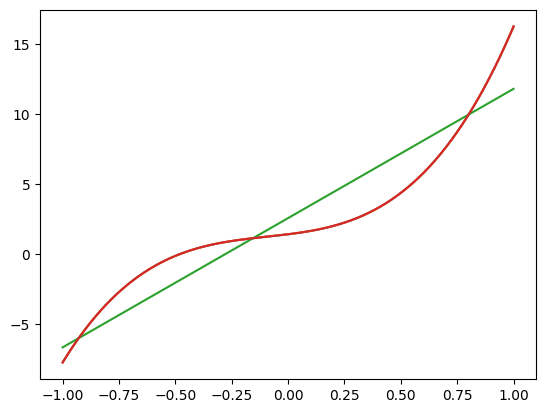

In [97]:
# question 5:

def fonction_approche(t,d,x):
  Y_app=res_least_square(t,d)[0]
  y_app=0
  for i in range (d+1):
    y_app+=Y_app[i]*x**i
  plt.plot(x,y_app)
  return y_app
fonction_approche(t,3,x)
fonction_approche(t,7,x)
fonction_approche(t,1,x)
fonction_approche(t,9,x)

16.48483131556997
14.312025078893681
15.544774424992632
10.716518055830775
12.71716775894149
14.71716775894149
16.717309992062233
18.71730999206222
20.717302554260787
22.717302554260783


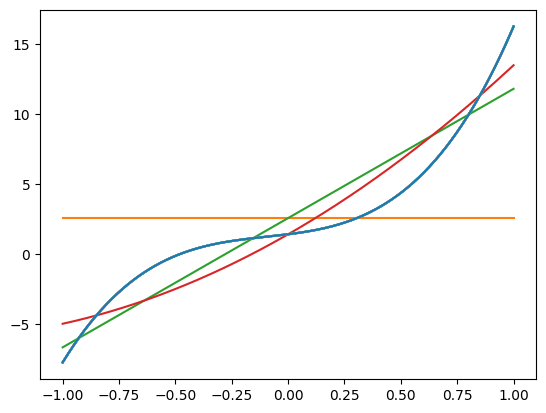

In [119]:
# question 6: Bonus
def residual(x,d):
  y=ytrue(x)
  y_app=fonction_approche(t,d,x)
  residual=(y-y_app)**2
  norme=np.linalg.norm(residual)
  return norme
residual(x,3)

def AIC(x,d):
  r=residual(x,d)
  p=d+1
  return 2*p+np.log(r**2)
for i in range (10):
  print(AIC(x,i))

# On peut alors choisir le min de la fonction ici pour d=4

### 2. Denoising

This second problem is the *denoising* problem which corresponds to the reconstruction of a signal $x(t)$ from noisy measurements $y(t) = x(t) + n(t)$, where $n(t)$ is some noise.
A typical assumption is that noise is Gaussian, i.e., for a given time instant $t_i$,  $n(t_i) \sim \mathcal{N}(0, \sigma^2)$ where $\sigma^2$ is the noise variance.

The denoising problem can be formulated as a least squares problem. Let $t_1, \ldots, t_N$ be $N$ time instants and denote by $\mathbf{x}, \mathbf{y}$ the vectors encoding the signal and the measurements, respectively. The denoising problem seeks to solve

$$\min_{\mathbf{x}\in\mathbb{R}^N} \Vert \mathbf{y}-\mathbf{x}\Vert^2_2$$

**Preliminary questions**
1. What is the solution to the least squares problem $\hat{\mathbf{x}}$?

Usually, we have access to extra information about the signal $\mathbf{x}$: e.g. it is non-negative, it belongs to some class of constraints, it exhibits regularity in some representation domain, etc.
A classical assumption is that the signal is smooth. At first order, this is encoded by the function
$$ r(\mathbf{x}) = \sum_{n=1}^{N-1} (x_{n+1}- x_{n})^2$$

2. Show that $r(\mathbf{x}) $ can be expressed as $r(\mathbf{x}) = \Vert \mathbf{D}_1\mathbf{x}\Vert^2_2$

To take into account the smoothness of the solution into the denoising problem, we formulate a new problem, called *regularized least squares* or *penalized least squares*. It reads
$$\min_{\mathbf{x}\in \mathbb{R}^N} \Vert \mathbf{y} - \mathbf{x}\Vert^2_2 + \lambda r(\mathbf{x}), \quad \lambda \geq 0$$
where
- $\Vert \mathbf{y}-\mathbf{x}\Vert$ is called the data fidelity term;
- $r(\mathbf{x})$ is the regularization (or penalty) and $\lambda\geq 0$ is called the regularization parameter.

3. Compute the solution to the regularized least squares problem above with $r(\mathbf{x}) = \Vert \mathbf{D}_1\mathbf{x}\Vert^2_2$. Comment on the uniqueness of the solution. What happens when $\lambda \rightarrow 0$? When $\lambda \rightarrow \infty$?

> Write here your answers to preliminary questions using Markdown

**Implementation tasks**

1. Generate a smooth signal $x(t) = \cos(2\pi f_0 t)$ where $f_0 = 5$ Hz and $t \in [0, 1]$ s. Choose a sampling frequency that satisfies the Shannon-Nyquist criterion.
2. Generate noisy measurements by corrupting the signal vector $\mathbf{x}$ by additive white Gaussian noise with SNR = 10 dB. (Recall the formula for the SNR!)
3. Solve the regularized least squares for different values of $\lambda$, and represent corresponding solutions. Compare it to the ground truth signal.  
4. A common question in penalized optimization problems is to choose the hyperparameter $\lambda$. A classical approach is to use a heuristic called L-curve: for various values of $\lambda$, plot the data fidelity term vs the penalty term in the cost function. From this tool, what would be a good choice of $\lambda$ according to you? Why?
5. Start again the exercise with the second-order penalty function
$$ r(\mathbf{x}) = \sum_{n=2}^{N-1} (x_{n+1}- 2x_{n} + x_{n-1})^2$$
Compare your results with the first-order difference penalty.

In [135]:
# question 1.

# On reecrit sous forme de somme la norme à minimiser et on derive par rapport aux xi.
# On obtient la condition necessaire suivante --> xi=yi
# Donc la solution minimale est ^x=y

In [143]:
# Question 2:

# Cf cahier
# calcul de la derivée de la fonction pour trouver le cas necessaire d'annulation du gradiant


[ 4.86874674  4.8382131   4.77258832  4.67089743  4.53440279  4.36585181
  4.16900699  3.94830887  3.70860345  3.4549057   3.19219034  2.92520984
  2.65834255  2.39547439  2.13991607  1.89435591  1.66084655  1.44082199
  1.23513995  1.04414381  0.8677379   0.70547014  0.55661651  0.42026251
  0.29537804  0.18088284  0.07570118 -0.02119512 -0.11075496 -0.19382684
 -0.27114693 -0.34333508 -0.41089685 -0.47423031 -0.53363581 -0.5893278
 -0.64144739 -0.690075   -0.73524242 -0.77694394 -0.8151463  -0.84979733
 -0.88083335 -0.90818528 -0.93178372 -0.95156299 -0.96746435 -0.97943848
 -0.98744743 -0.99146601 -0.99148287 -0.98750118 -0.97953916 -0.96763029
 -0.95182346 -0.93218294 -0.9087882  -0.88173369 -0.85112849 -0.81709596
 -0.77977317 -0.73931046 -0.69587078 -0.64962905 -0.60077148 -0.54949481
 -0.49600552 -0.44051898 -0.38325863 -0.32445503 -0.26434497 -0.20317048
 -0.14117789 -0.07861684 -0.01573923  0.04720176  0.10995266  0.17226079
  0.23387523  0.29454782  0.35403413  0.41209439  0.

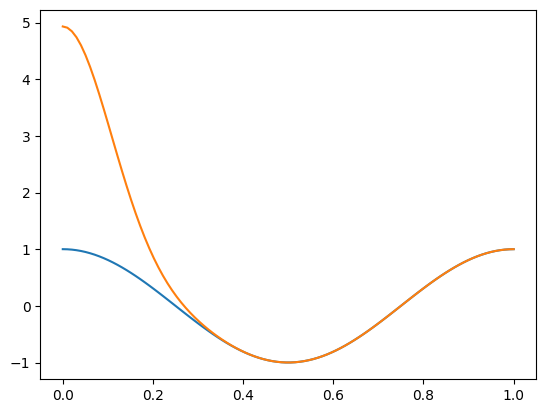

In [158]:
# question 3:
def x(t):
  f0=100‡
  return np.cos(2*np.pi*f0*t)
t=np.linspace(0,1,100)
plt.plot(t,x(t))

def y(h):
  sigma=(((np.linalg.norm(h**2))**2/10)*10**(-1))**1/2
  err=stats.norm.pdf(h, scale=sigma)
  return x(h)+err
h=np.linspace(0,1,100)
plt.plot(h,y(h))


I=np.identity(100)
lamb=2
D1=-1*I + np.eye(100, k=1)
res=np.linalg.solve(I+lamb*D1.T@D1,y(h))
print(res)


In [157]:
# question 4

In [ ]:
# question 5